## Task
### Data Loading and Cleaning:

- Load the dataset using Pandas.
- Perform basic data cleaning (handling missing values, incorrect data types, etc.).

### Exploratory Data Analysis (EDA):

- Use Pandas to summarize the key statistics of the dataset.
- Identify unique values, ranges, and distribution of data.

### Visualization Tasks:

- Species Distribution: Use a bar chart to show the distribution of penguin species.
- Flipper Length vs. Body Mass: Create a scatter plot to analyze the relationship between flipper length and body mass, color-coded by species.
- Island Distribution: Visualize the count of penguins on each island using a pie chart.
- Sex Distribution within Species: Create grouped bar charts showing the distribution of sex within each penguin species.
- Heatmap of Correlations: Plot a heatmap to visualize the correlations between numerical variables.
- Boxplots for Measurements: Generate boxplots for flipper length, body mass, and bill measurements, segmented by species.
- Histograms of Measurements: Create histograms to show the distribution of key measurements (bill length, bill depth, flipper length).

### Insightful Visualizations:

- Combine multiple plots into a single figure (using subplots) to compare different aspects of the data.
- Use Seaborn’s pairplot to visualize pairwise relationships in the dataset.


### Solution

In [28]:
# ============================================
# RUN THIS CELL FIRST - All imports for today
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Set default figure size
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries loaded! Ready for visualization.")

All libraries loaded! Ready for visualization.


In [29]:
# First look at the data
penguins = sns.load_dataset('penguins')

penguins.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


In [30]:
penguins.shape

(344, 7)

In [31]:
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [32]:
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [33]:
# Check for missing values
print("Missing values by column:")
print(penguins.isnull().sum())
number_missing = penguins.isnull().any(axis=1).sum()

print(f"\nRows with any missing: {number_missing}")

Missing values by column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Rows with any missing: 11


In [34]:
# Print percentage of missing rows

total_penguins = penguins.shape[0]
percentage = number_missing/total_penguins * 100
print(f"Percentage of missing data: {percentage.round(1)}%")

# Since percentage < 5%, we can safely drop the missing rows
penguins = penguins.dropna()

number_missing = penguins.isnull().any(axis=1).sum()
print(f"\nRows with any missing after drop: {number_missing}")


Percentage of missing data: 3.2%

Rows with any missing after drop: 0


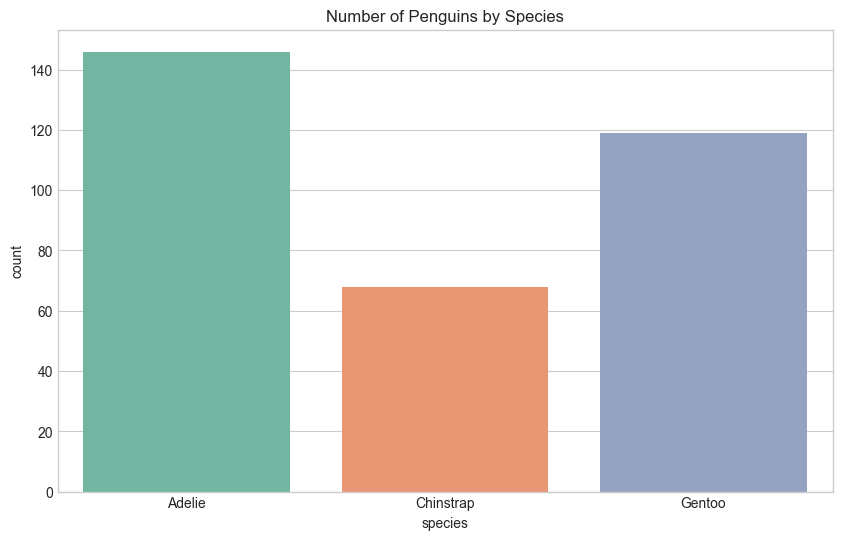

In [52]:
# Create a bar chart for the distribution of penguin species
plt.figure(figsize=(10, 6))
sns.countplot(data=penguins, x='species', hue='species', palette='Set2')
plt.title('Number of Penguins by Species')
plt.show()

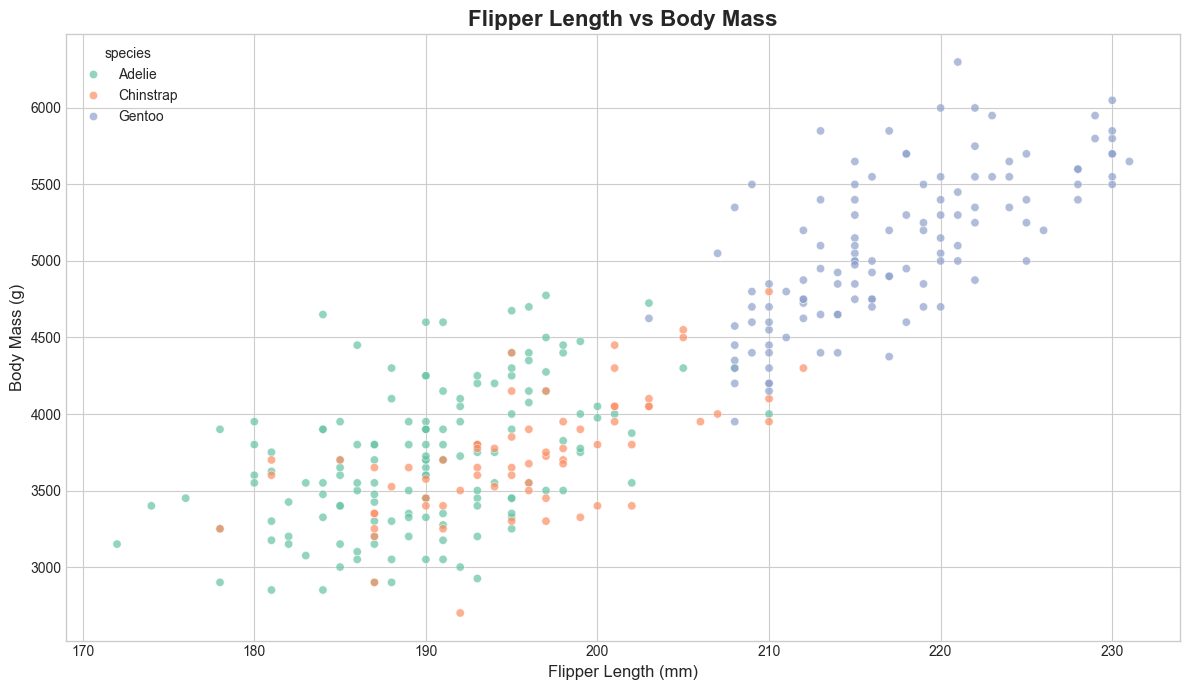

In [38]:
plt.figure(figsize=(12, 7))

sns.scatterplot(data=penguins, x='flipper_length_mm', y='body_mass_g',
                hue='species', alpha=0.7, palette='Set2')

plt.title('Flipper Length vs Body Mass', fontsize=16, fontweight='bold')
plt.xlabel('Flipper Length (mm)', fontsize=12)
plt.ylabel('Body Mass (g)', fontsize=12)

plt.tight_layout()
plt.show()

**Observation**: The scatterplot suggests a strong linear relationship between flipper length and body mass, with the Adelie and Chinstrap species on the lower ranges of flipper lentgh, and consequently on the lower ranges of body mass as well.

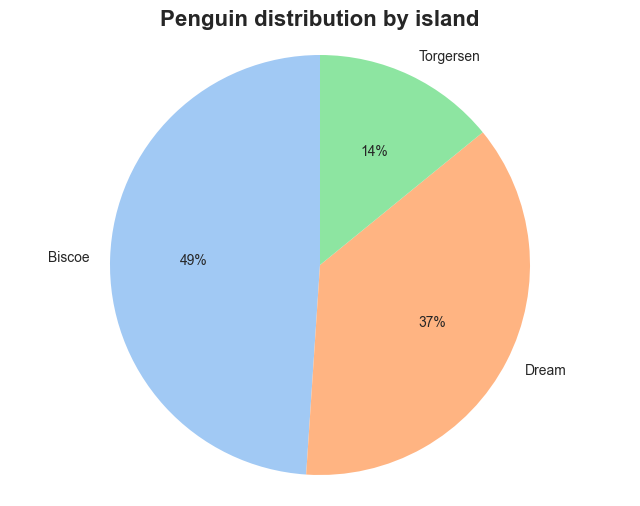

In [50]:
# Group penguin count per island
penguins_island = penguins.groupby('island')['species'].size().reset_index()

# Choose color palette for pie chart 
colors = sns.color_palette('pastel')[0:len(penguins_island['island'])]

# Plot pie chart
plt.figure(figsize=(8, 6))

plt.pie(x=penguins_island['species'], labels=penguins_island['island'], colors=colors, autopct='%.0f%%', startangle=90)

plt.title('Penguin distribution by island', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.show()



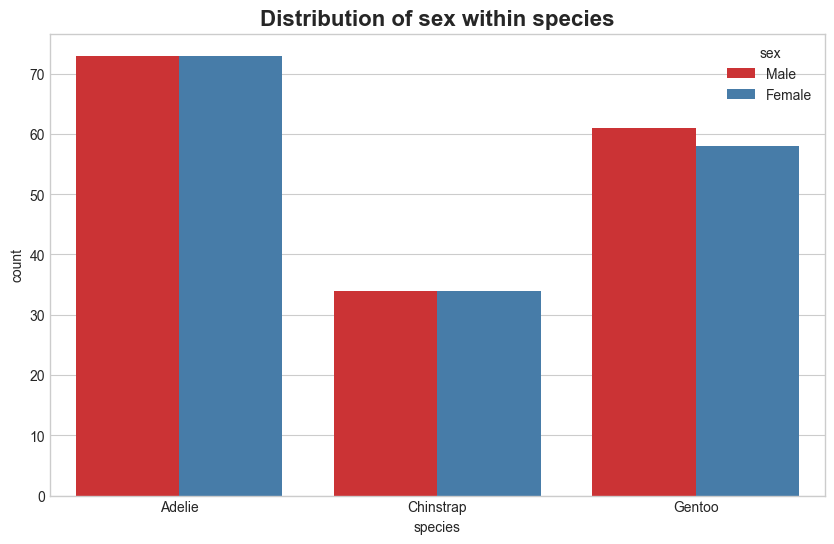

In [77]:

# Create bar chart for species count grouped by sex
plt.figure(figsize=(10, 6))

sns.countplot(data=penguins, x='species', hue='sex', palette='Set1')
plt.title('Distribution of sex within species', fontsize=16, fontweight='bold')
plt.show()


**Observation**: We can see in bar chart above that sex is equally distributed among species.

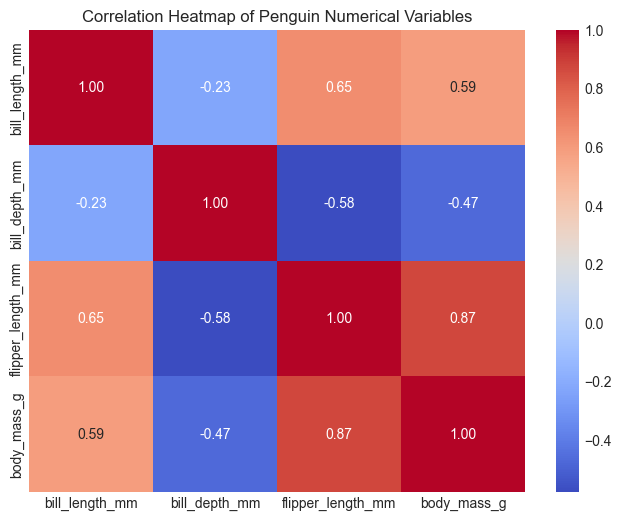

In [81]:
# Select only the numerical variables and compute the correlation matrix
# The 'corr()' method automatically handles numerical data.
# The 'numeric_only=True' parameter ensures non-numeric types are excluded.
correlation_matrix = penguins.corr(numeric_only=True)

# Create the heatmap
plt.figure(figsize=(8, 6)) # Optional: Adjust the figure size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
# annot=True adds the correlation values to the cells
# cmap='coolwarm' sets a diverging color map
# fmt=".2f" formats the annotations to two decimal places

# Add a title and display the plot
plt.title("Correlation Heatmap of Penguin Numerical Variables")
plt.show()

**Observation**: The heatmap shows a strong positive correlation between (in descending order of correlation strength):
- flipper length and body mass;
- bill length and flipper length;
- bill length and body mass.

Those positive correlations seem to align to common sense intuition.

On the other hand, it also showed a weak negative correlation between bill length and bill depth, a moderate negative correlation between body mass and bill depth, and a strong negative correlation between bill depth and flipper length. From the naive standpoint of a non-specialist, those negative correlations are surprising.

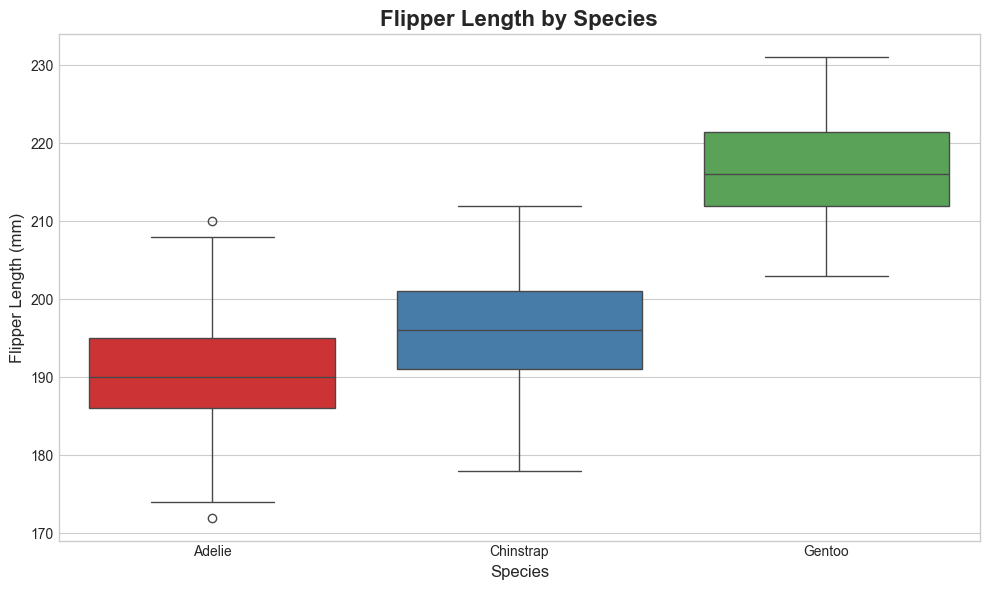

In [83]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=penguins, x='species', y='flipper_length_mm', hue='species', palette='Set1', legend=False)

plt.title('Flipper Length by Species', fontsize=16, fontweight='bold')
plt.xlabel('Species', fontsize=12)
plt.ylabel('Flipper Length (mm)', fontsize=12)

plt.tight_layout()
plt.show()

**Observation**: The bloxplots show that the flipper length has larger values in the Gentoo species than the other two (which rougly have the same range of values).

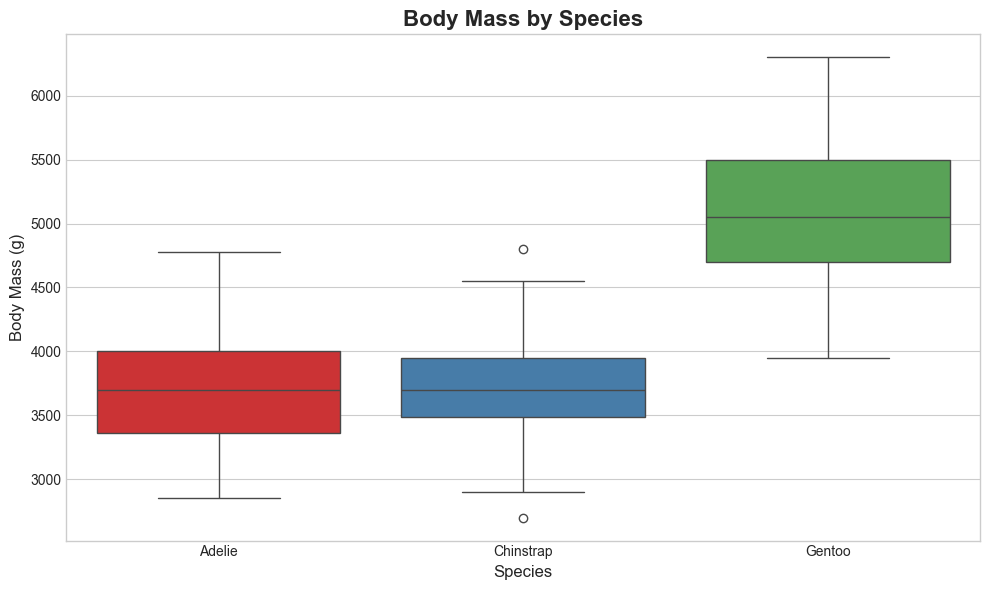

In [84]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=penguins, x='species', y='body_mass_g',
            hue='species', palette='Set1', legend=False)

plt.title('Body Mass by Species', fontsize=16, fontweight='bold')
plt.xlabel('Species', fontsize=12)
plt.ylabel('Body Mass (g)', fontsize=12)

plt.tight_layout()
plt.show()

**Observation**: The bloxplots show that the body mass has larger values in the Gentoo species than the other two (which rougly have the same range of values).

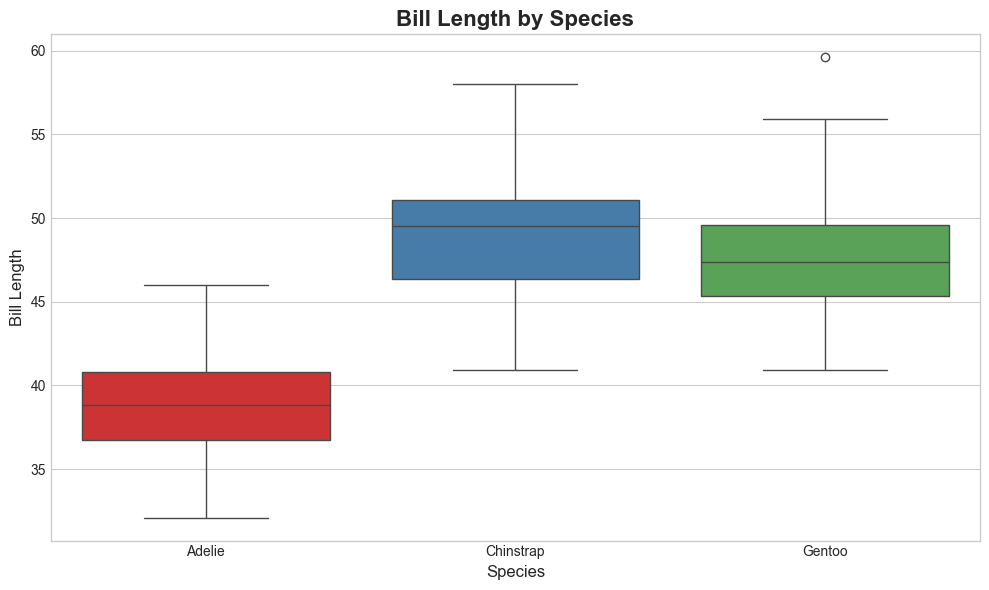

In [85]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=penguins, x='species', y='bill_length_mm',
            hue='species', palette='Set1', legend=False)

plt.title('Bill Length by Species', fontsize=16, fontweight='bold')
plt.xlabel('Species', fontsize=12)
plt.ylabel('Bill Length', fontsize=12)

plt.tight_layout()
plt.show()

**Observation**: The bloxplots suggest that both the Chistrap and the Gentoo species have in general bigger values of bill length than the Adelie species.

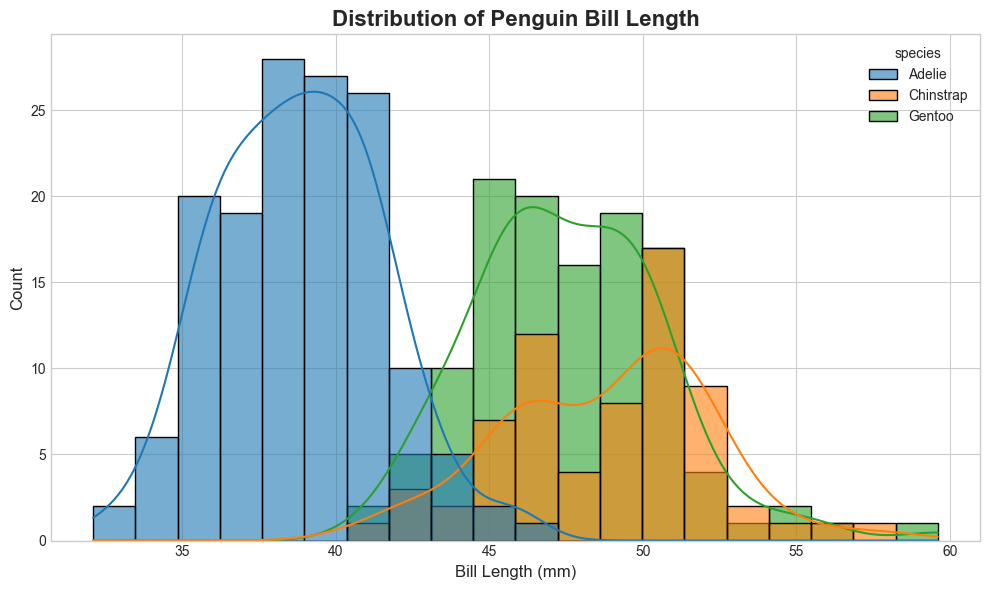

In [87]:
plt.figure(figsize=(10, 6))

sns.histplot(data=penguins, x='bill_length_mm', hue='species', bins=20, color='steelblue',alpha=0.6, kde=True)
plt.title("Distribution of Penguin Bill Length", fontsize=16, fontweight='bold')
plt.xlabel("Bill Length (mm)", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.tight_layout()
plt.show()

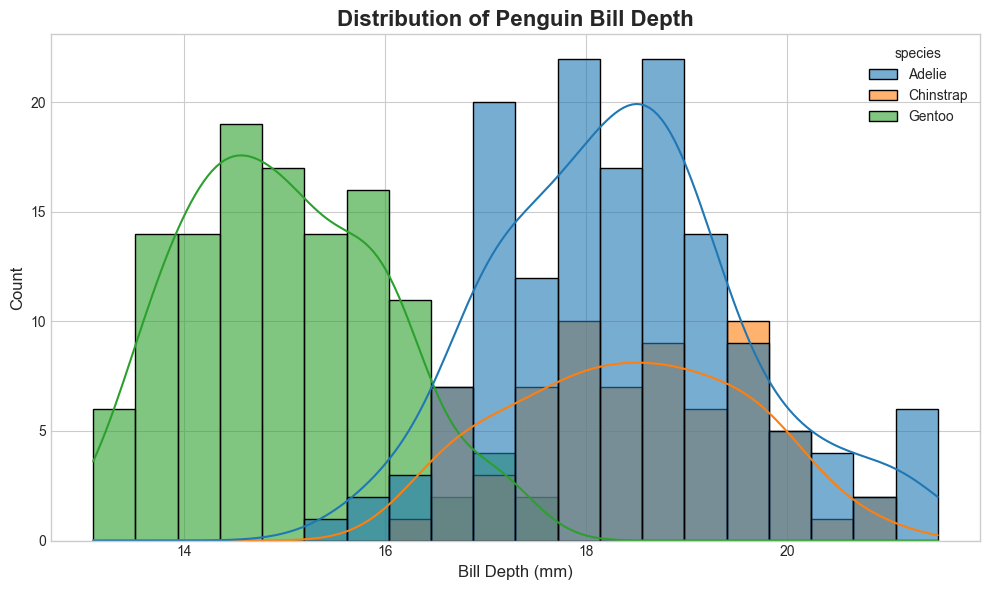

In [88]:
plt.figure(figsize=(10, 6))

sns.histplot(data=penguins, x='bill_depth_mm', hue='species', bins=20, color='steelblue',alpha=0.6, kde=True)
plt.title("Distribution of Penguin Bill Depth", fontsize=16, fontweight='bold')
plt.xlabel("Bill Depth (mm)", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.tight_layout()
plt.show()

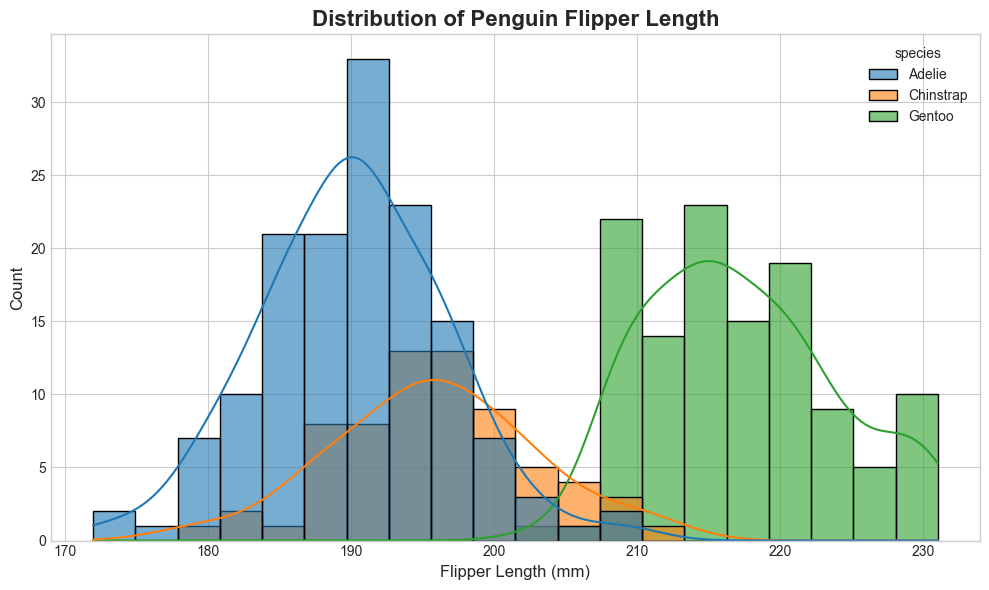

In [89]:
plt.figure(figsize=(10, 6))

sns.histplot(data=penguins, x='flipper_length_mm', hue='species', bins=20, color='steelblue',alpha=0.6, kde=True)
plt.title("Distribution of Penguin Flipper Length", fontsize=16, fontweight='bold')
plt.xlabel("Flipper Length (mm)", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.tight_layout()
plt.show()

**Observation**: all three histograms show a bimodal distribution according to species.

/var/folders/8g/b0fs32r14l57mfjp3l9lh_nw0000gn/T/ipykernel_62486/1178439688.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penguins, x='species', y='body_mass_g',


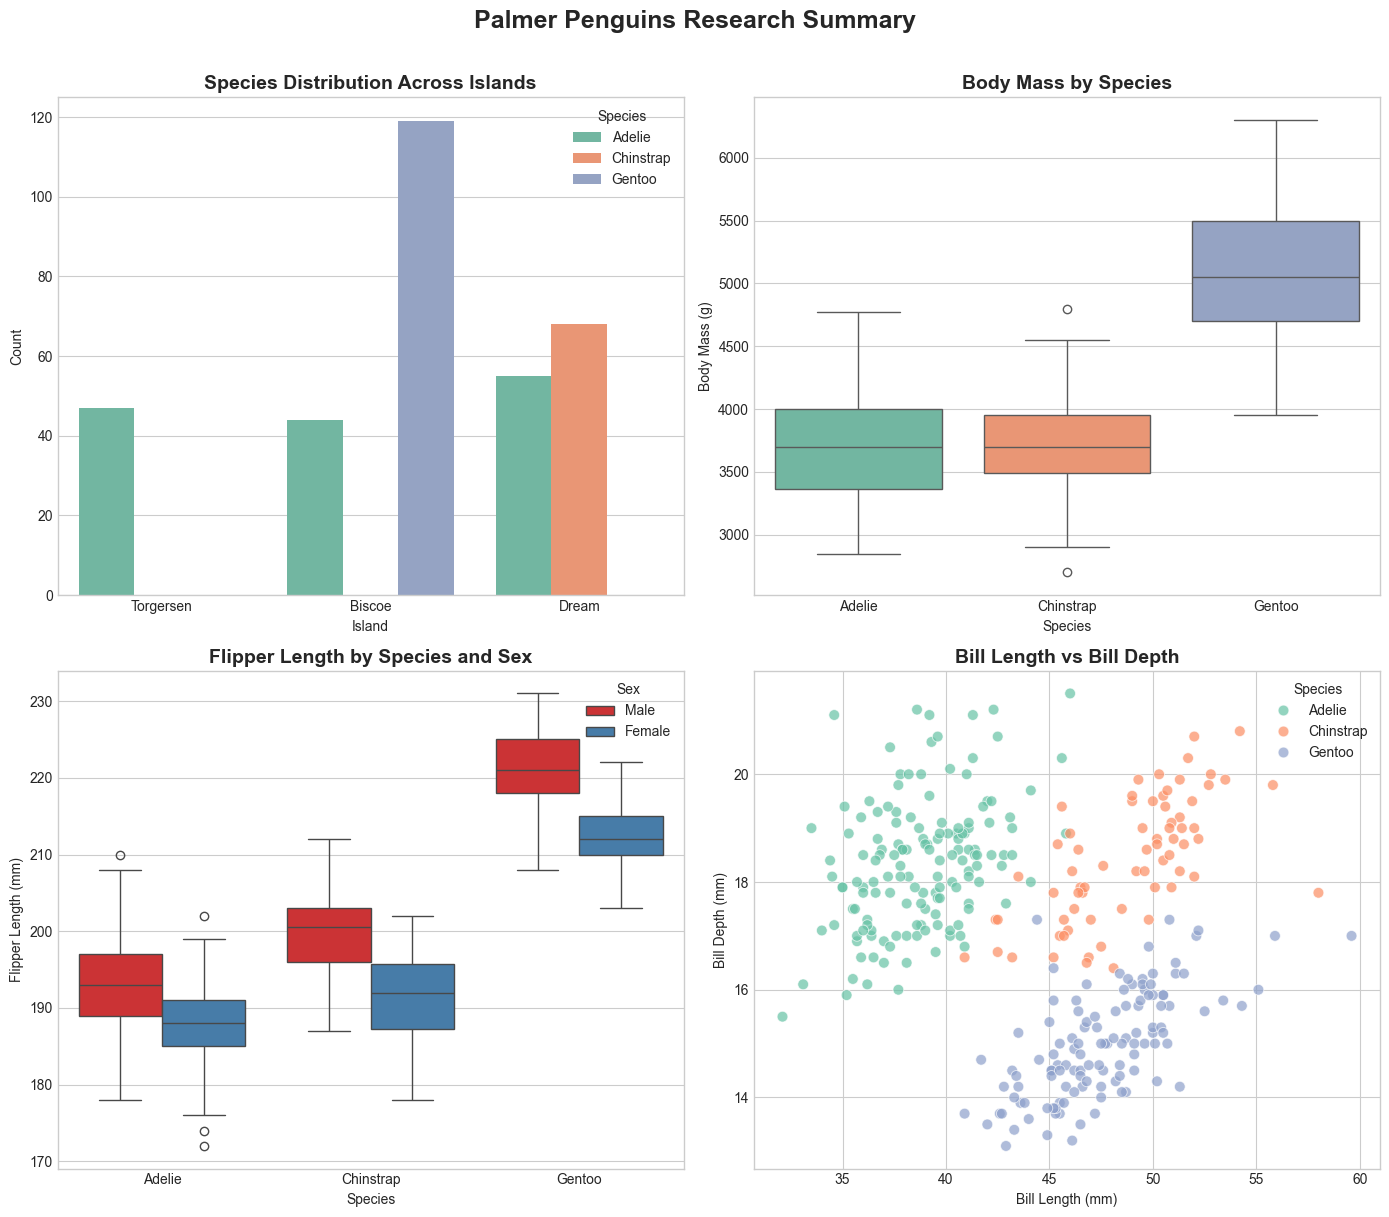

Key findings:
  1. Species have distinct geographic preferences
  2. Gentoo are significantly larger than other species
  3. Sexual dimorphism present in all species (males larger)
  4. Bill shape differs markedly between species


In [90]:
# Complete Penguin Research Dashboard

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. TOP-LEFT: Species distribution across islands
sns.countplot(data=penguins, x='island', hue='species',
              palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Species Distribution Across Islands', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Island')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend(title='Species')

# 2. TOP-RIGHT: Body mass comparison
sns.boxplot(data=penguins, x='species', y='body_mass_g',
            palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Body Mass by Species', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Species')
axes[0, 1].set_ylabel('Body Mass (g)')

# 3. BOTTOM-LEFT: Sexual dimorphism
sns.boxplot(data=penguins, x='species', y='flipper_length_mm',
            hue='sex', palette='Set1', ax=axes[1, 0])
axes[1, 0].set_title('Flipper Length by Species and Sex', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Species')
axes[1, 0].set_ylabel('Flipper Length (mm)')
axes[1, 0].legend(title='Sex')

# 4. BOTTOM-RIGHT: Bill dimensions (Simpson's Paradox!)
sns.scatterplot(data=penguins, x='bill_length_mm', y='bill_depth_mm',
                hue='species', palette='Set2', s=60, alpha=0.7, ax=axes[1, 1])
axes[1, 1].set_title('Bill Length vs Bill Depth', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Bill Length (mm)')
axes[1, 1].set_ylabel('Bill Depth (mm)')
axes[1, 1].legend(title='Species')

plt.suptitle('Palmer Penguins Research Summary', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Key findings:")
print("  1. Species have distinct geographic preferences")
print("  2. Gentoo are significantly larger than other species")
print("  3. Sexual dimorphism present in all species (males larger)")
print("  4. Bill shape differs markedly between species")

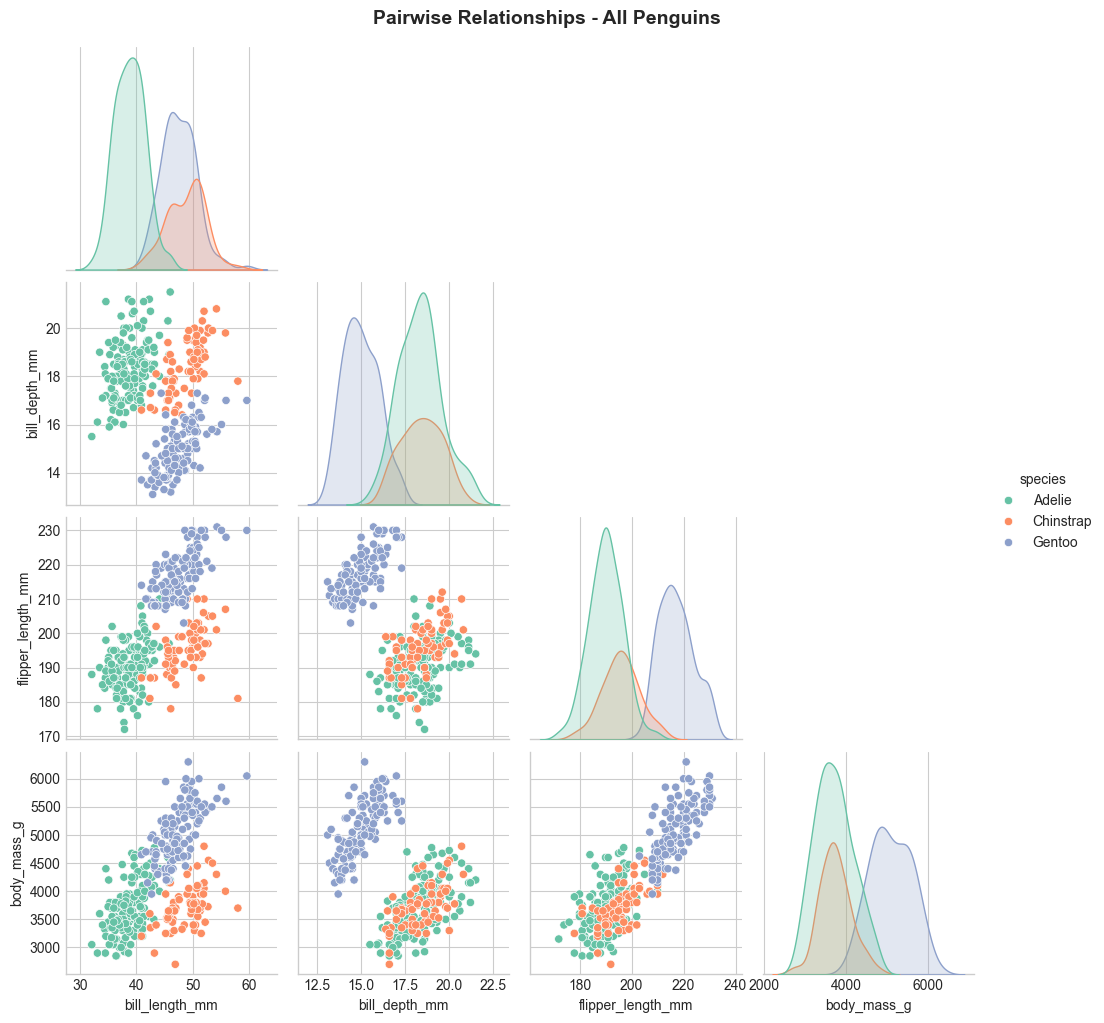

Diagonal = distributions, Off-diagonal = scatter plots


In [ ]:
# Corner plot - removes redundant upper triangle
sns.pairplot(penguins, hue='species',
             vars=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'],
             corner=True, height=2.5, palette='Set2')

plt.suptitle('Pairwise Relationships - All Penguins', y=1.02, fontsize=14, fontweight='bold')
plt.show()

print("Diagonal = distributions, Off-diagonal = scatter plots")

**Observation**: All for variables show a pair-wise strong linear relationship within species, with the linearity between species with rougly the same rate of change (parellel or coinciding lines). 